# Trabajo Practico Nº2 - PDI (Grupo 6)
Integrantes: Añaños Diego, Quinteros Facundo, Lasarte Roberto

# 0. Importaciónes de Librerias a Usar

In [55]:
import os
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Detección y clasificación de pastillas

### A. Segmentar el área de la cinta transportadora (ROI) en donde se encuentran las pastillas.

In [56]:
def imshow(img, new_fig=True, title=None, color_img=False, blocking=False, colorbar=False, ticks=False):
  if new_fig:
    plt.figure()
  if color_img:
    plt.imshow(img)
  else:
    plt.imshow(img, cmap='gray')
  plt.title(title)
  if not ticks:
    plt.xticks([]), plt.yticks([])
  if colorbar:
    plt.colorbar()
  if new_fig:
    plt.show(block=blocking)

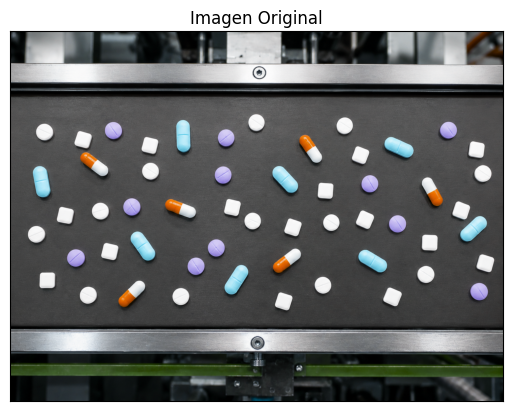

In [57]:
pastillas = cv2.imread("pills.png")
pastillas_RGB = cv2.cvtColor(pastillas, cv2.COLOR_BGR2RGB)
imshow(pastillas, title="Imagen Original", color_img=True)

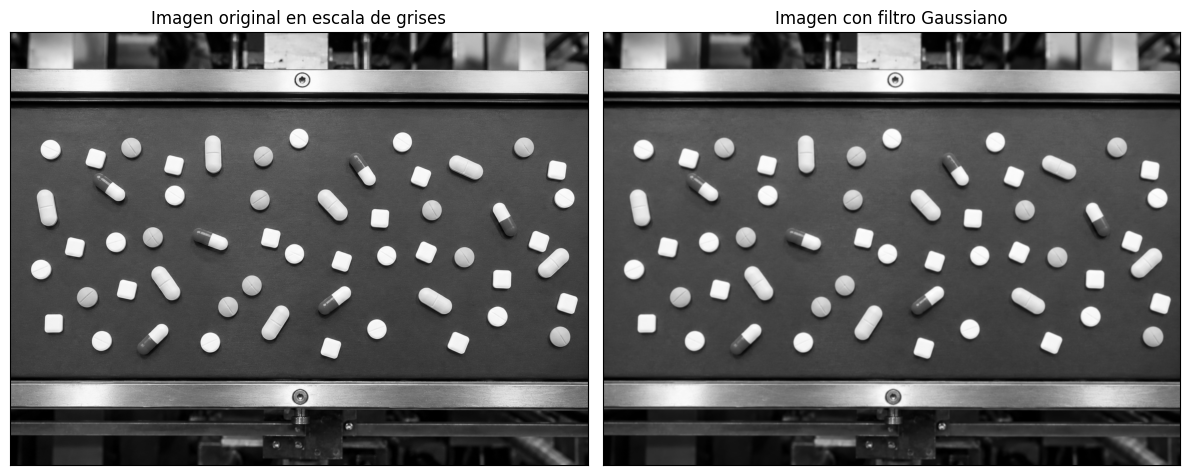

In [58]:
pastillas_gris = cv2.imread('pills.png', cv2.IMREAD_GRAYSCALE)
blur = cv2.GaussianBlur(pastillas_gris, (5,5), 0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
imshow(pastillas_gris, new_fig=False, title='Imagen original en escala de grises', color_img=False)
plt.subplot(1, 2, 2)
imshow(blur, new_fig=False, title='Imagen con filtro Gaussiano', color_img=False)

plt.tight_layout()
plt.show()

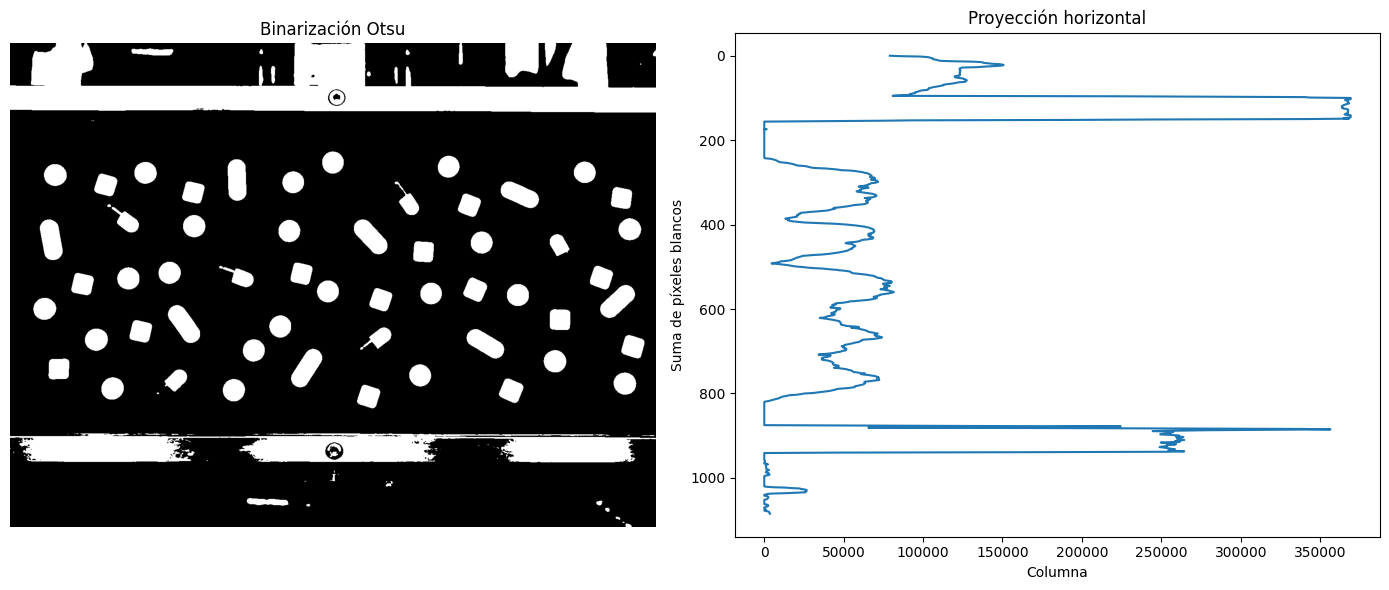

In [59]:
_, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
horizontal_projection = np.sum(mask, axis=1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap='gray')
plt.title('Binarización Otsu')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.plot(horizontal_projection, np.arange(len(horizontal_projection)))
plt.gca().invert_yaxis()
plt.title('Proyección horizontal')
plt.xlabel('Columna')
plt.ylabel('Suma de píxeles blancos')

plt.tight_layout()
plt.show()

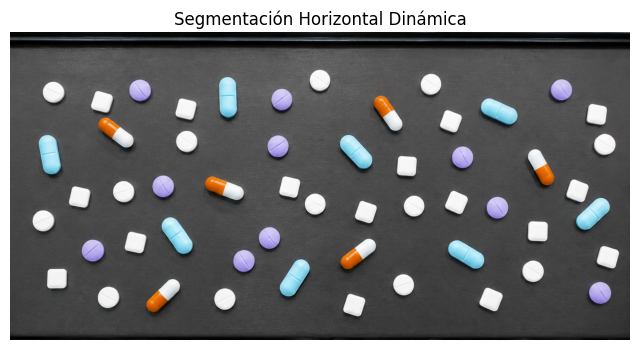

In [60]:
# Se divide el vector a la mitad para aislar el pico izquierdo del derecho
mitad = len(horizontal_projection) // 2

# Se encuentra la posición exacta (índice) de los dos picos más altos
pico_izquierdo = np.argmax(horizontal_projection[:mitad])
pico_derecho = np.argmax(horizontal_projection[mitad:]) + mitad

# Se define un umbral adaptativo basado en la altura de los picos
# Si el pico mide 350.000, el 5% es 17.500. Todo lo que esté abajo es piso/valle.
umbral_corte = 0.05 * horizontal_projection[pico_izquierdo]

# Se busca el corte superior avanzando a la derecha desde el primer pico
# hasta que la señal caiga por debajo del umbral (fin de la barra)
indices_despues_pico1 = np.where(horizontal_projection[pico_izquierdo:] < umbral_corte)[0]
corte_superior = pico_izquierdo + indices_despues_pico1[0]

# Se busca el corte inferior retrocediendo a la izquierda desde el segundo pico
# hasta que la señal caiga por debajo del umbral (inicio de la barra)
indices_antes_pico2 = np.where(horizontal_projection[:pico_derecho] < umbral_corte)[0]
corte_inferior = indices_antes_pico2[-1]

# Se realiza el recorte final limpio de la imagen original usando los cortes detectados
pastillas_ROI = pastillas[corte_superior:corte_inferior, :]

plt.figure(figsize=(8, 8))
plt.imshow(pastillas_ROI, cmap='gray')
plt.title('Segmentación Horizontal Dinámica')
plt.axis('off')
plt.show()

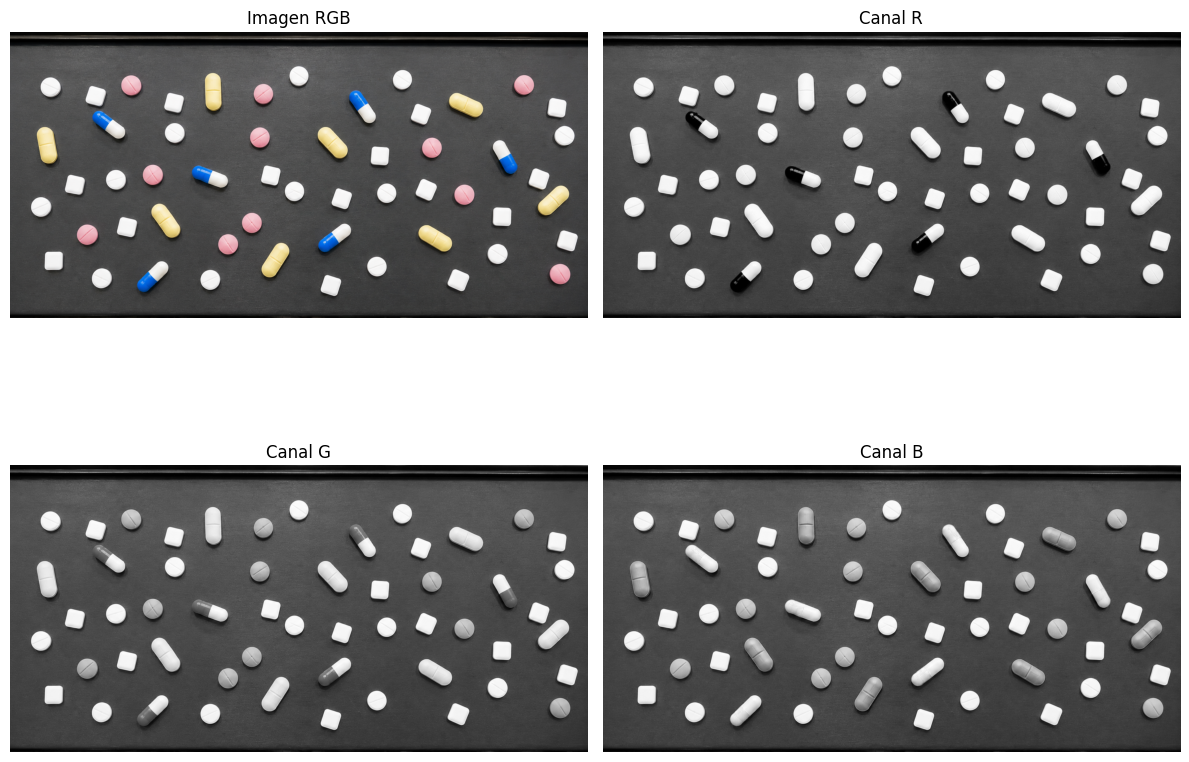

In [61]:
pastillas_ROI_RGB = cv2.cvtColor(pastillas_ROI, cv2.COLOR_BGR2RGB)
B, G, R = cv2.split(pastillas_ROI)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()
titles = ["Imagen RGB", "Canal R", "Canal G", "Canal B"]
imagenes = [pastillas_ROI_RGB, R, G, B]
for idx, (ax, img, title) in enumerate(zip(axs, imagenes, titles)):
  if idx == 0:
    ax.imshow(img)
  else:
    ax.imshow(img, cmap="gray")
  ax.set_title(title)
  ax.axis("off")
plt.tight_layout()
plt.show()

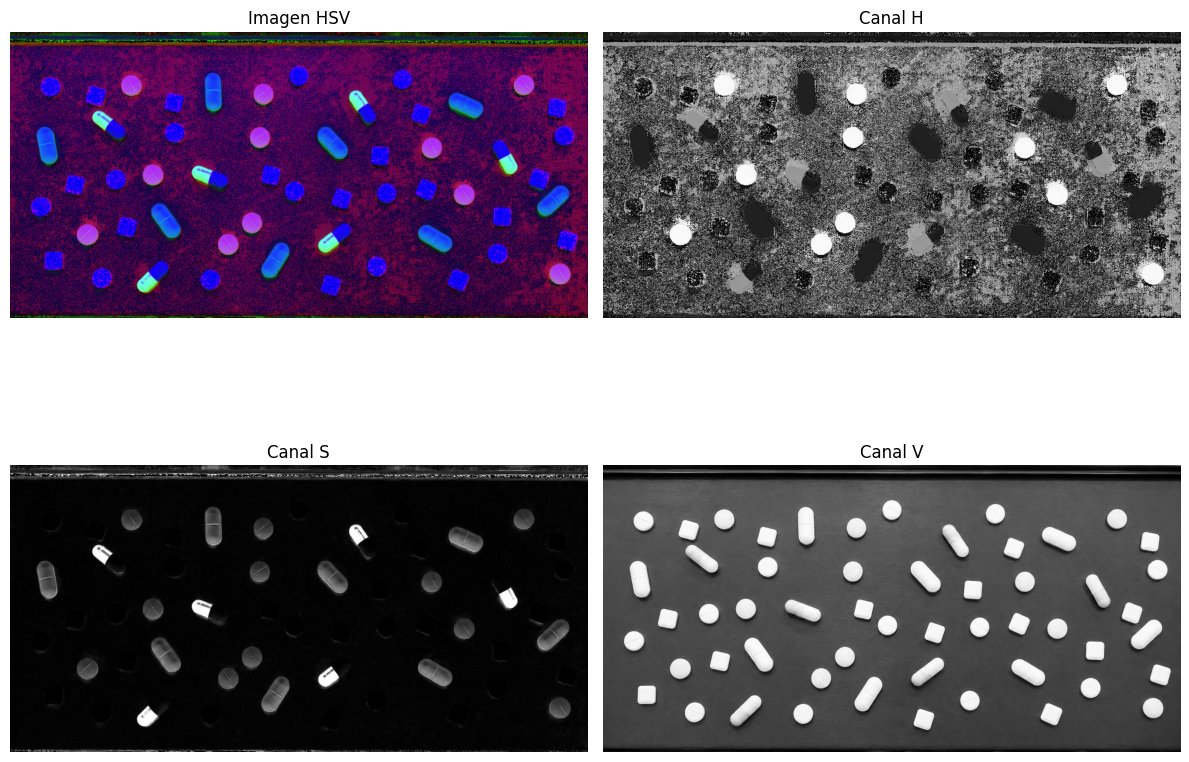

In [62]:
pastillas_ROI_HSV = cv2.cvtColor(pastillas_ROI, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(pastillas_ROI_HSV)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()
titles = ["Imagen HSV", "Canal H", "Canal S", "Canal V"]
imagenes = [pastillas_ROI_HSV, H, S, V]
for idx, (ax, img, title) in enumerate(zip(axs, imagenes, titles)):
  if idx == 0:
    ax.imshow(img)
  else:
    ax.imshow(img, cmap="gray")
  ax.set_title(title)
  ax.axis("off")
plt.tight_layout()
plt.show()

### B. Detectar y segmentar individualmente cada una de las pastillas presentes.

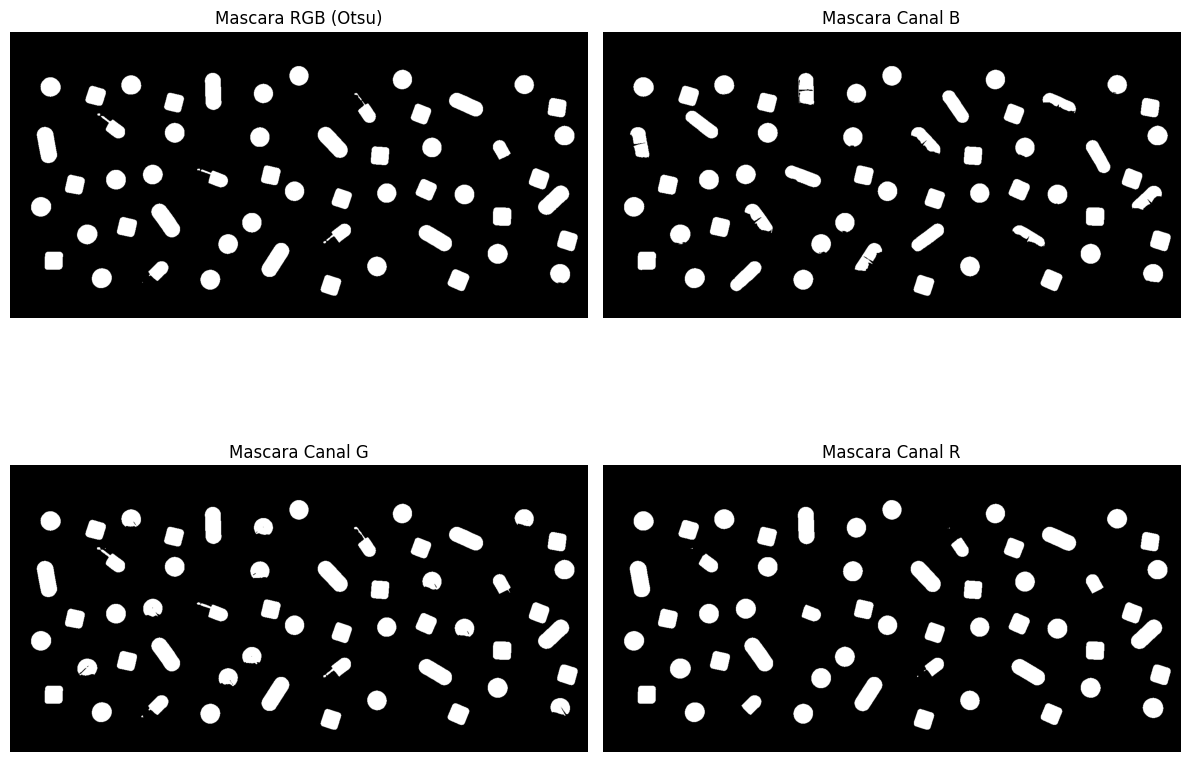

In [63]:
pastillas_ROI_RGB_gris = cv2.cvtColor(pastillas_ROI_RGB, cv2.COLOR_RGB2GRAY)
pastillas_ROI_RGB_gris_blur = cv2.GaussianBlur(pastillas_ROI_RGB_gris, ksize=(3, 3), sigmaX=1.5)
_, mask_ROI_RGB = cv2.threshold(pastillas_ROI_RGB_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_B_gris_blur = cv2.GaussianBlur(B, ksize=(3, 3), sigmaX=1.5)
_, mask_ROI_B = cv2.threshold(pastillas_ROI_B_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_G_gris_blur = cv2.GaussianBlur(G, ksize=(3, 3), sigmaX=1.5)
_, mask_ROI_G = cv2.threshold(pastillas_ROI_G_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_R_gris_blur = cv2.GaussianBlur(R, ksize=(3, 3), sigmaX=1.5)
_, mask_ROI_R = cv2.threshold(pastillas_ROI_R_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()
titles = ["Mascara RGB (Otsu)", "Mascara Canal B", "Mascara Canal G", "Mascara Canal R"]
masks = [mask_ROI_RGB, mask_ROI_B, mask_ROI_G, mask_ROI_R]

for ax, mask_img, title in zip(axs, masks, titles):
  ax.imshow(mask_img, cmap='gray')
  ax.set_title(title)
  ax.axis('off')

plt.tight_layout()
plt.show()

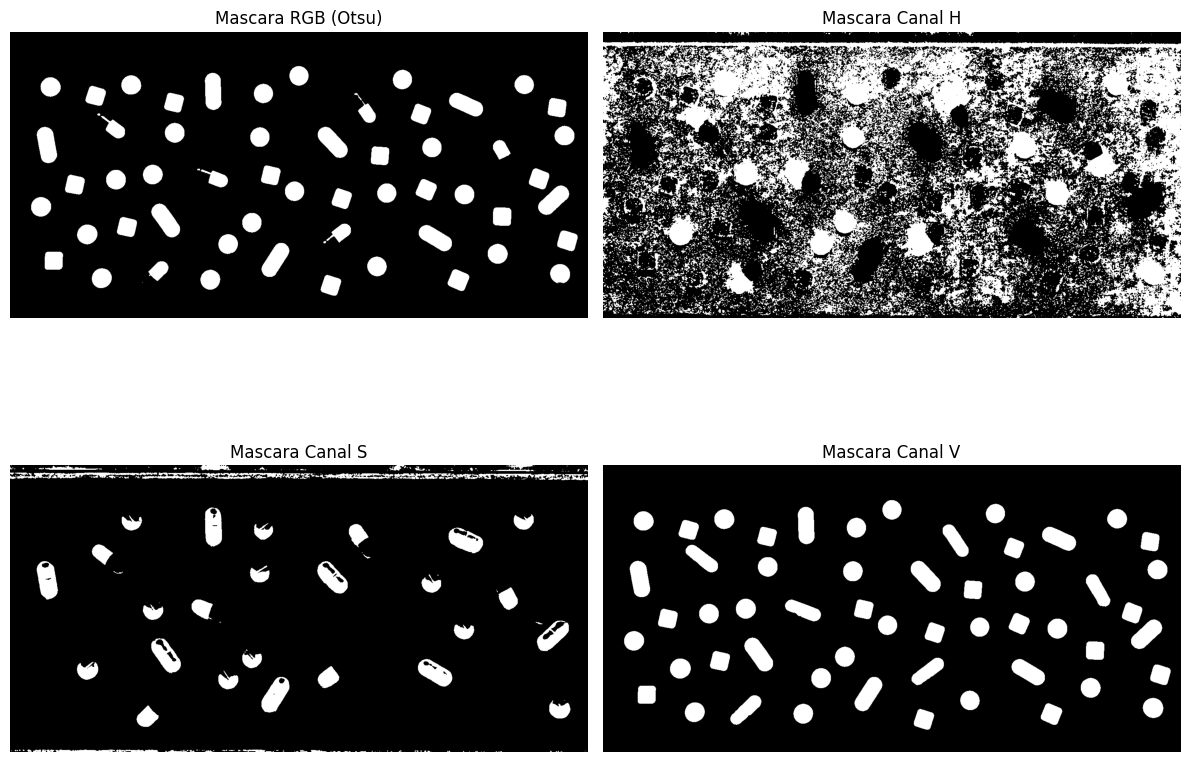

In [64]:
pastillas_ROI_H_gris_blur = cv2.GaussianBlur(H, ksize=(3, 3), sigmaX=1.5)
_, mask_ROI_H = cv2.threshold(pastillas_ROI_H_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_S_gris_blur = cv2.GaussianBlur(S, ksize=(3, 3), sigmaX=1.5)
_, mask_ROI_S = cv2.threshold(pastillas_ROI_S_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_V_gris_blur = cv2.GaussianBlur(V, ksize=(3, 3), sigmaX=1.5)
_, mask_ROI_V = cv2.threshold(pastillas_ROI_V_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()
titles = ["Mascara RGB (Otsu)", "Mascara Canal H", "Mascara Canal S", "Mascara Canal V"]
masks = [mask_ROI_RGB, mask_ROI_H, mask_ROI_S, mask_ROI_V]

for ax, mask_img, title in zip(axs, masks, titles):
  ax.imshow(mask_img, cmap='gray')
  ax.set_title(title)
  ax.axis('off')

plt.tight_layout()
plt.show()

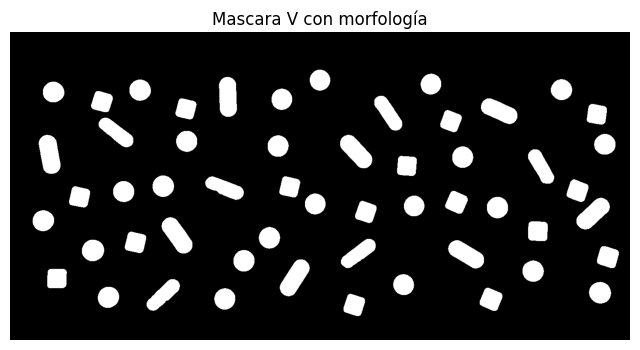

In [65]:
kernel = np.ones((3,3), np.uint8)

mask_final = cv2.morphologyEx(mask_ROI_V, cv2.MORPH_CLOSE, kernel)
mask_final = cv2.morphologyEx(mask_final, cv2.MORPH_OPEN, kernel)
plt.figure(figsize=(8, 8))
plt.imshow(mask_final, cmap='gray')
plt.title('Mascara V con morfología')
plt.axis('off')
plt.show()

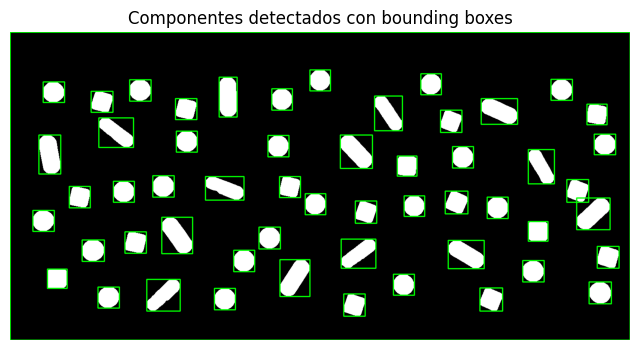

In [66]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_final, connectivity=8)

mask_clean_color = cv2.cvtColor(mask_final, cv2.COLOR_GRAY2BGR)
for st in stats:
  cv2.rectangle(mask_clean_color, (st[0], st[1]), (st[0]+st[2], st[1]+st[3]), color=(0,255,0), thickness=2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(mask_clean_color, cv2.COLOR_BGR2RGB))
plt.title('Componentes detectados con bounding boxes')
plt.axis('off')
plt.show()

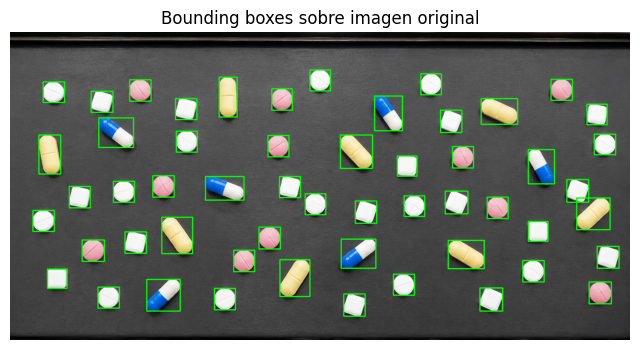

Número de pastillas: 54


In [67]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_final, connectivity=8)

img_boxes = pastillas_ROI_RGB.copy()

for st in stats[1:]:
  x, y, w, h, area = st
  cv2.rectangle(img_boxes, (x, y), (x + w, y + h), color=(0,255,0), thickness=2)

plt.figure(figsize=(8, 8))
plt.imshow(img_boxes)
plt.title('Bounding boxes sobre imagen original')
plt.axis('off')
plt.show()

print(f"Número de pastillas: {num_labels - 1}")

### C. Clasificar los distintos tipos de pastillas y realizar un conteo total de cada tipo.

In [68]:
imagenes_separadas = []
for i in range(1, num_labels):
  obj = (labels == i).astype(np.uint8)
  imagenes_separadas.append(obj)

pastillas_redondas = []
pastillas_cuadradas = []
pastillas_ovaladas = []

for img_individual in imagenes_separadas:
  contornos, _ = cv2.findContours(img_individual, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if not contornos:
    continue
  cnt = contornos[0]
  area_real = cv2.contourArea(cnt)
  if area_real == 0:
    continue

  # Se obtiene el Bounding Box Rotado Real (Detecta pastillas alargadas independientemente de su orientación)
  rect_rotado = cv2.minAreaRect(cnt)
  (_, _), (ancho, alto), _ = rect_rotado # (centro_x, centro_y), (ancho, alto), angulo_rotacion
  if ancho == 0 or alto == 0:
    continue
  largo = max(ancho, alto)
  ancho_corto = min(ancho, alto)
  relacion_forma = largo / ancho_corto
  # Si es notablemente más larga que ancha, es OVALADA
  if relacion_forma > 1.35:
    pastillas_ovaladas.append(img_individual)
    continue

  # Se clasifica lo que queda (Círculos y Cuadrados)
  area_caja_rotada = largo * ancho_corto
  ocupacion = area_real / area_caja_rotada
  # Un círculo ocupa ~0.78 de su caja, un cuadrado ocupa ~0.92
  if ocupacion > 0.85:
    pastillas_cuadradas.append(img_individual)
  else:
    pastillas_redondas.append(img_individual)

  ## Factor de Forma - con contorno suavizado para reducir ruido (Más escalable que el método de relación de aspecto + ocupación, pero más sensible a ruido)
  #epsilon = 0.005 * cv2.arcLength(cnt, True)
  #cnt_suave = cv2.approxPolyDP(cnt, epsilon, True)
  
  #perimetro = cv2.arcLength(cnt_suave, True)
  #if perimetro == 0:
  #  continue
  #factor_forma = area_real / (perimetro ** 2)

  #if factor_forma > 0.074:
  #  pastillas_redondas.append(img_individual)
  #else:
  #  pastillas_cuadradas.append(img_individual)

print(f"Redondas: {len(pastillas_redondas)} - Cantidad real: 24")
print(f"Cuadradas: {len(pastillas_cuadradas)} - Cantidad real: 16")
print(f"Ovaladas: {len(pastillas_ovaladas)} - Cantidad real: 14")

Redondas: 24 - Cantidad real: 24
Cuadradas: 16 - Cantidad real: 16
Ovaladas: 14 - Cantidad real: 14


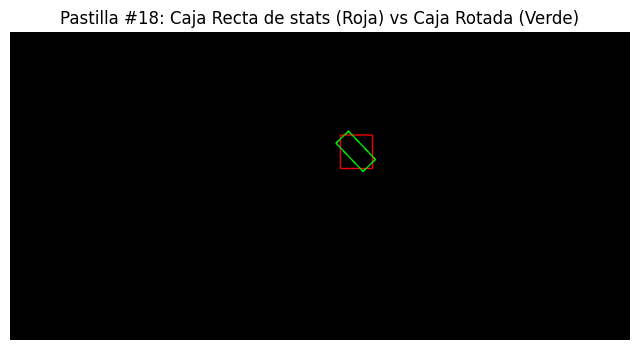

Caja Recta (Roja): Ancho = 75 px, Alto = 78 px
Relación de aspecto (Caja Recta): 1.04
----------------------------------------
Caja Rotada (Verde): Lado A = 40.3 px, Lado B = 91.4 px
Relación de aspecto (Caja Rotada Real): 2.27


In [69]:
# Ejemplo de visualización de una pastilla ovalada con minAreaRect
img_individual = imagenes_separadas[18]
imagen_color = cv2.cvtColor(img_individual, cv2.COLOR_GRAY2BGR)
# Caja Recta color ROJO
x, y, w, h = cv2.boundingRect(img_individual)
cv2.rectangle(imagen_color, (x, y), (x + w, y + h), (0, 0, 255), 2)

# Caja Rotada color VERDE
contornos, _ = cv2.findContours(img_individual, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = contornos[0]
rect_rotado = cv2.minAreaRect(cnt)
esquinas_caja = cv2.boxPoints(rect_rotado) # Convertir las propiedades del rectángulo rotado a 4 coordenadas (esquinas) para dibujarlo
esquinas_caja = np.int64(esquinas_caja)
cv2.drawContours(imagen_color, [esquinas_caja], 0, (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB))
plt.title(f"Pastilla #18: Caja Recta de stats (Roja) vs Caja Rotada (Verde)")
plt.axis("off")
plt.show()

print(f"Caja Recta (Roja): Ancho = {w} px, Alto = {h} px")
relacion_recta = max(w, h) / min(w, h)
print(f"Relación de aspecto (Caja Recta): {relacion_recta:.2f}")
print("-" * 40)
(_, _), (ancho_r, alto_r), _ = rect_rotado
print(f"Caja Rotada (Verde): Lado A = {ancho_r:.1f} px, Lado B = {alto_r:.1f} px")
relacion_rotada = max(ancho_r, alto_r) / min(ancho_r, alto_r)
print(f"Relación de aspecto (Caja Rotada Real): {relacion_rotada:.2f}")

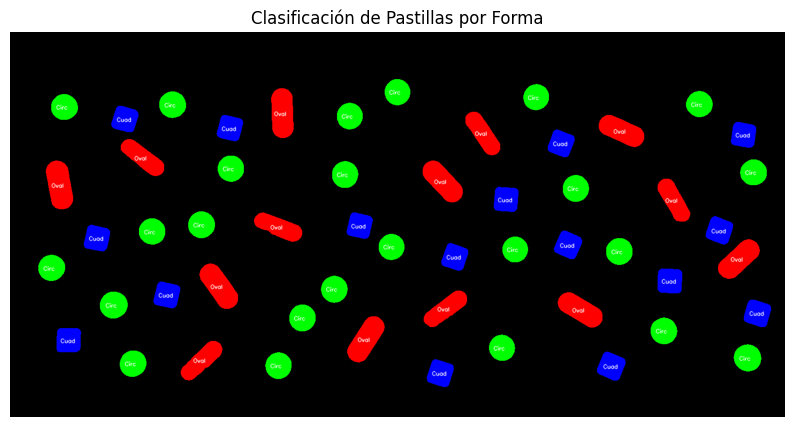

In [70]:
h, w = imagenes_separadas[0].shape
imagen_visualizacion = np.zeros((h, w, 3), dtype=np.uint8)

# Formato BGR
COLOR_REDONDO = (0, 255, 0)  # Verde
COLOR_CUADRADO = (255, 0, 0)  # Azul
COLOR_OVALADO = (0, 0, 255)  # Rojo

# Función auxiliar para pintar y etiquetar la pastilla en la imagen final
def etiquetar_pastilla(img_individual, texto, color):
  # Encontrar el contorno y su centroide (Moments) para saber dónde escribir
  contornos, _ = cv2.findContours(img_individual, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if contornos:
    cnt = contornos[0]
    # Dibujar el contorno relleno en la imagen de visualización para ver la pastilla
    cv2.drawContours(imagen_visualizacion, [cnt], -1, color, thickness=-1)
    # Calcular el centro del objeto usando momentos
    M = cv2.moments(cnt)
    if M["m00"] != 0:
      cX = int(M["m10"] / M["m00"])
      cY = int(M["m01"] / M["m00"])
      # Escribir la etiqueta de texto centrada (desplazada un poco a la izquierda y arriba)
      cv2.putText(imagen_visualizacion, texto, (cX - 15, cY + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.35, 
                  (255, 255, 255), 1, cv2.LINE_AA,)

# Procesar y etiquetar cada grupo clasificado
for img in pastillas_redondas:
    etiquetar_pastilla(img, "Circ", COLOR_REDONDO)
for img in pastillas_cuadradas:
    etiquetar_pastilla(img, "Cuad", COLOR_CUADRADO)
for img in pastillas_ovaladas:
    etiquetar_pastilla(img, "Oval", COLOR_OVALADO)

plt.figure(figsize=(10, 10))
imagen_rgb = cv2.cvtColor(imagen_visualizacion, cv2.COLOR_BGR2RGB)
plt.imshow(imagen_rgb)
plt.title("Clasificación de Pastillas por Forma")
plt.axis("off")
plt.show()